# Spectral Features Extraction & Evaluation

This notebook is segmented into two parts:
1. **Single-Pair Pipeline Test**: Evaluating two arbitrary code chunks on the fly using the unified `Pipeline`.
2. **Batch Dataset Analysis**: Loading the extracted JSON datasets (AST, CFG, DDG, PDG) generated by `extract_dataset.py` and analyzing graph extraction performances and metrics.

In [3]:
import json
import random
import pandas as pd

from pathlib import Path


In [4]:
DATA_DIR = Path("data")

JSONL_PATH = DATA_DIR / "data.jsonl"
TRAIN_PATH = DATA_DIR / "train.txt"

In [5]:
code_map = {}

with open(JSONL_PATH, "r", encoding="utf-8") as f:
    for line in f:
        item = json.loads(line)
        code_map[item["idx"]] = item["func"]

In [6]:
train_pairs = []

with open(TRAIN_PATH, "r", encoding="utf-8") as f:
    for line in f:
        i1, i2, label = line.strip().split()
        train_pairs.append((str(i1), str(i2), int(label)))

In [7]:
idx1, idx2, label = random.choice(train_pairs)

code1 = code_map[idx1]
code2 = code_map[idx2]

print("Label:", label)
print("\n--- CODE 1 ---\n", code1[:300])
print("\n--- CODE 2 ---\n", code2[:300])

Label: 0

--- CODE 1 ---
     public void convert(File src, File dest) throws IOException {
        InputStream in = new BufferedInputStream(new FileInputStream(src));
        DcmParser p = pfact.newDcmParser(in);
        Dataset ds = fact.newDataset();
        p.setDcmHandler(ds.getDcmHandler());
        try {
            F

--- CODE 2 ---
     public static HttpURLConnection createSoapHttpURLConnection(String url) throws MalformedURLException, IOException {
        HttpURLConnection connection = (HttpURLConnection) new URL(url).openConnection();
        connection.setRequestMethod("POST");
        connection.addRequestProperty("Connec


In [8]:
from spectral_code.pipeline import Pipeline
from spectral_code.config import PipelineConfig

In [9]:
config = PipelineConfig(
    graph_type="ast",
    spectral_mode="laplacian",
    eigen_solver="sparse",
    k_eigen=20,
)

pipeline = Pipeline(config)

In [10]:
result1 = pipeline.run(code1, lang="java")
result2 = pipeline.run(code2, lang="java")

In [11]:
eig1 = result1["eigenvalues"]
eig2 = result2["eigenvalues"]

In [12]:
import numpy as np

# align lengths (important because eigsh returns k values)
k = min(len(eig1), len(eig2))

distance = np.linalg.norm(eig1[:k] - eig2[:k])

print("Spectral distance:", distance)
print("Ground truth label:", label)

Spectral distance: 3.8971304624752614
Ground truth label: 0


---
## Batch Dataset Analysis
Evaluating the pre-extracted JSON features from the outputs folder.

In [3]:
import os
import sys
import json
import pandas as pd
import networkx as nx
from tqdm.notebook import tqdm

BASE_DIR = os.getcwd()
if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)

from spectral_code.utils.dataset import load_graph_from_json

FEATURES_DIR = os.path.abspath(os.path.join(BASE_DIR, "outputs", "dataset_features"))
GRAPH_TYPES = ["ast", "cfg", "ddg", "pdg"]

def load_full_dataset_with_benchmarks():
    json_files = [f for f in os.listdir(FEATURES_DIR) if f.endswith(".json")]
    print(f"[*] Total JSON files found on disk: {len(json_files)}")
    
    loaded_dataset = {}
    metrics_list = []

    for file_name in tqdm(json_files, desc="Processing Dataset"):
        json_path = os.path.join(FEATURES_DIR, file_name)
        idx = os.path.splitext(file_name)[0]
        
        try:
            with open(json_path, "r", encoding="utf-8") as f:
                raw_json = json.load(f)
        except Exception:
            continue

        ast_raw = raw_json.get("features", {}).get("ast", {})
        if ast_raw is None or ast_raw.get("graph_data") is None:
            continue
            
        method_layers = {}
        
        for gtype in GRAPH_TYPES:
            graph = load_graph_from_json(json_path, graph_type=gtype)
            method_layers[gtype] = graph
            
            n_nodes = graph.number_of_nodes() if graph else 0
            n_edges = graph.number_of_edges() if graph else 0
            
            layer_raw = raw_json.get("features", {}).get(gtype, {})
            time_metrics = layer_raw.get("metrics", {}) if layer_raw else {}
            
            cpg_time = time_metrics.get("cpg_time", 0.0)
            export_time = time_metrics.get("export_time", 0.0)
            
            metrics_list.append({
                "method_id": idx,
                "layer": gtype,
                "node_count": n_nodes,
                "edge_count": n_edges,
                "cpg_time_s": cpg_time,
                "export_time_s": export_time,
                "total_time_s": cpg_time + export_time
            })

        loaded_dataset[idx] = method_layers
            
    df_metrics = pd.DataFrame(metrics_list)
    return loaded_dataset, df_metrics

loaded_dataset, df_metrics = load_full_dataset_with_benchmarks()

print(f"\n[+] Loading Complete!")
print(f"[+] Valid methods loaded into RAM: {len(loaded_dataset)}")
print(f"[+] Benchmark rows captured: {len(df_metrics)}")

[*] Total JSON files found on disk: 9126


Processing Dataset:   0%|          | 0/9126 [00:00<?, ?it/s]


[+] Loading Complete!
[+] Valid methods loaded into RAM: 9098
[+] Benchmark rows captured: 36392


In [4]:
# Let's inspect the very first method in our loaded dataset
first_method_id = list(loaded_dataset.keys())[0]
first_method_layers = loaded_dataset[first_method_id]

print(f"--- Inspection for Method ID: {first_method_id} ---")
for layer_name, graph in first_method_layers.items():
    if graph is not None:
        print(f"Layer '{layer_name.upper()}':")
        print(f"  └── Total Nodes (Tokens/Statements): {graph.number_of_nodes()}")
        print(f"  └── Total Edges (Connections)     : {graph.number_of_edges()}")
    else:
        print(f"Layer '{layer_name.upper()}': Empty/None")

--- Inspection for Method ID: 10000832 ---
Layer 'AST':
  └── Total Nodes (Tokens/Statements): 1129
  └── Total Edges (Connections)     : 1128
Layer 'CFG':
  └── Total Nodes (Tokens/Statements): 493
  └── Total Edges (Connections)     : 549
Layer 'DDG':
  └── Total Nodes (Tokens/Statements): 445
  └── Total Edges (Connections)     : 2332
Layer 'PDG':
  └── Total Nodes (Tokens/Statements): 483
  └── Total Edges (Connections)     : 2766


---
## Visualize Sample Graphs
Selecting a random function from the dataset and rendering its 4 graph types (AST, CFG, DDG, PDG) down below.

Visualizing Graphs for Method ID: 2467280


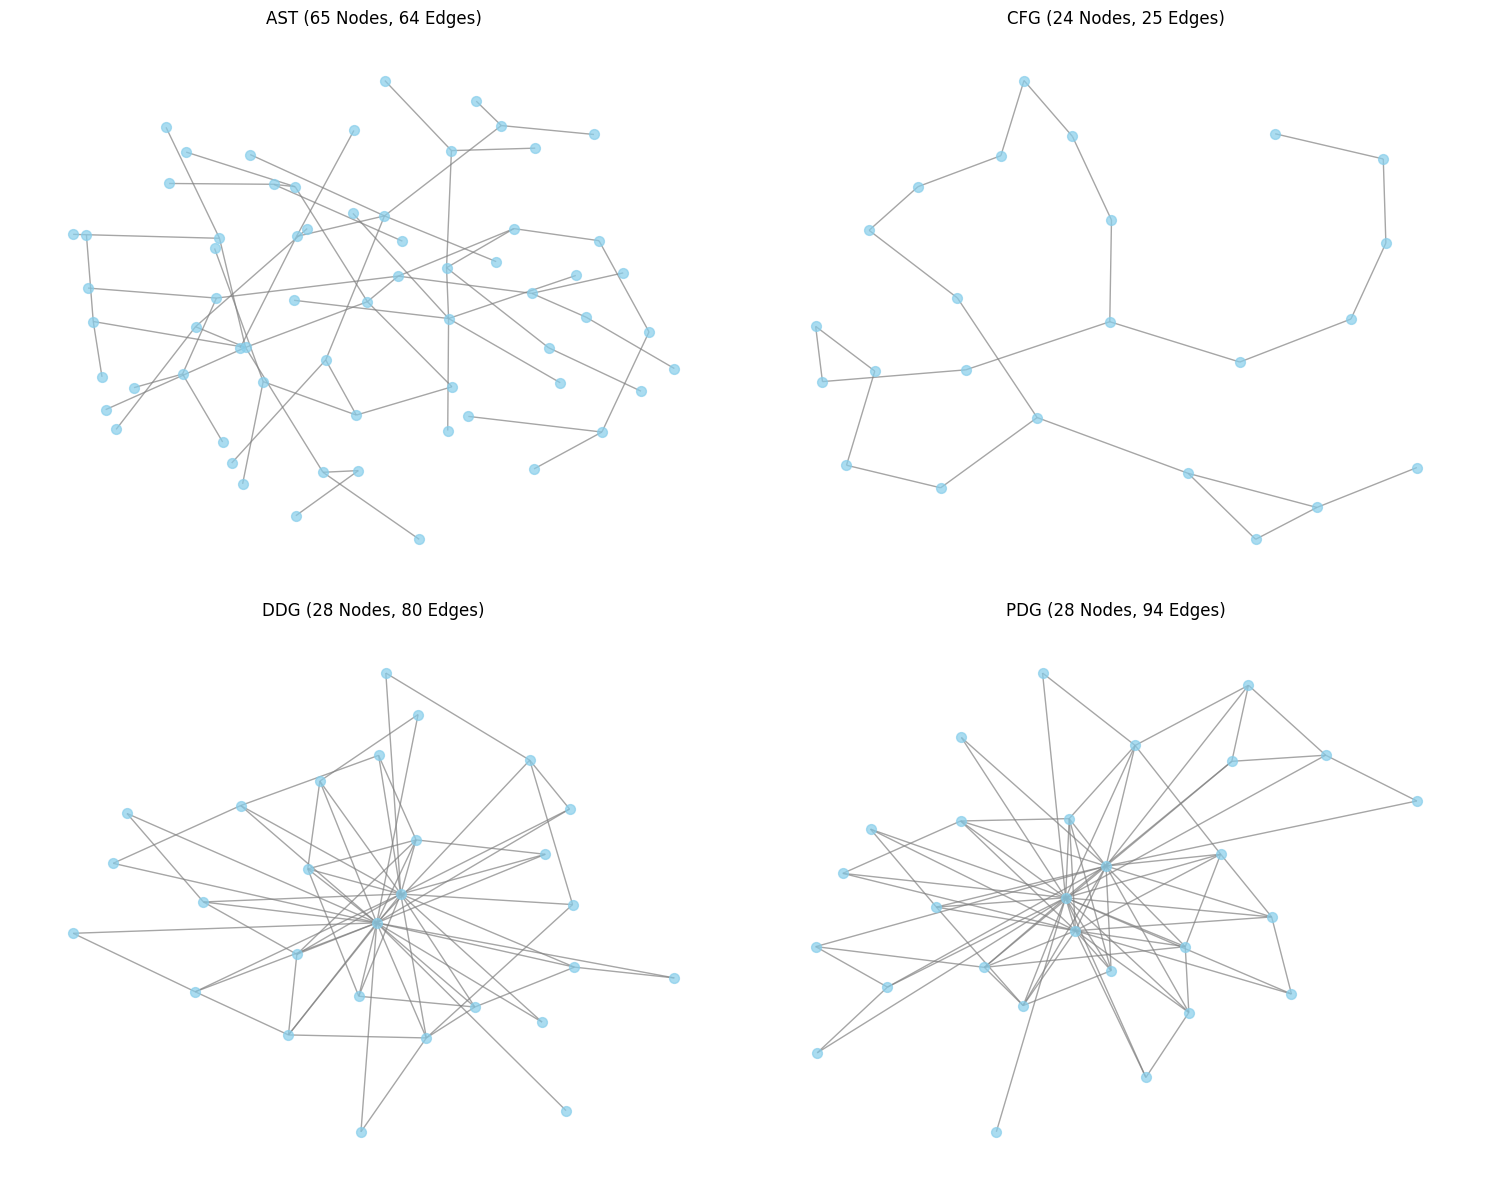

In [14]:
import random
import matplotlib.pyplot as plt
import networkx as nx

# Select a random valid method from the loaded dataset
sample_id = random.choice(list(loaded_dataset.keys()))
sample_graphs = loaded_dataset[sample_id]

print(f"Visualizing Graphs for Method ID: {sample_id}")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, gtype in enumerate(["ast", "cfg", "ddg", "pdg"]):
    ax = axes[i]
    graph = sample_graphs.get(gtype)
    
    if graph is not None and graph.number_of_nodes() > 0:
        # Undirected version for visualization
        G_vis = nx.Graph(graph.to_undirected())
        pos = nx.spring_layout(G_vis, k=0.5, iterations=50)
        
        # We can extract labels to show on nodes (optional, keeping it simple for now)
        nx.draw(G_vis, pos, ax=ax, node_size=50, node_color="skyblue", 
                edge_color="gray", with_labels=False, alpha=0.7)
        ax.set_title(f"{gtype.upper()} ({graph.number_of_nodes()} Nodes, {graph.number_of_edges()} Edges)")
    else:
        ax.set_title(f"{gtype.upper()} (Empty/Invalid)")
        ax.axis('off')

plt.tight_layout()
plt.show()